In [70]:
import numpy as np
import os
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow import keras
import datetime

from keras.layers import Conv2D, BatchNormalization, LeakyReLU, Conv2DTranspose, ReLU, Dropout
from keras.models import Sequential

In [2]:
train_image_path = "/mnt/e/Deep Learning/data/fecades/trainA"
len(os.listdir(train_image_path))

400

In [3]:
train_fecade_path = "/mnt/e/Deep Learning/data/fecades/trainB"
len(os.listdir(train_fecade_path))

400

In [4]:
test_image_path = "/mnt/e/Deep Learning/data/fecades/testA"
test_fecade_path = "/mnt/e/Deep Learning/data/fecades/testB"

print(len(os.listdir(test_image_path)))
print(len(os.listdir(test_fecade_path)))

106
106


In [7]:
train_images_path = "/mnt/e/Deep Learning/data/fecades/train_images"
test_images_path = "/mnt/e/Deep Learning/data/fecades/test_images"
os.makedirs(test_images_path, exist_ok=True)
os.makedirs(train_images_path, exist_ok=True)

In [ ]:
for name in sorted(os.listdir(train_image_path)):
    image_path = os.path.join(train_image_path, name)
    image = cv2.imread(image_path)

    name_fecad = name.replace("A", "B")
    fecade_path = os.path.join(train_fecade_path, name_fecad)

    if not os.path.exists(fecade_path):
        print(f"Fecade image for {name} doesnt exist!")

    fecade = cv2.imread(fecade_path)

    if image.shape != fecade.shape:
        print(f"Shape of {name} and its facade image are different.")

    height, width, channel = image.shape
    zero = np.zeros(shape=(height, 2 * width, 3), dtype=np.uint8)
    zero[:, :256, :] = image
    zero[:, 256:, :] = fecade

    out_name = name.split("_")[0]
    out_path = os.path.join(train_images_path, out_name + ".jpg")

    cv2.imwrite(out_path, zero)
    print(f"Image {out_path} saved!")


Image /mnt/e/Deep Learning/data/fecades/train_images/100.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/train_images/101.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/train_images/102.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/train_images/103.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/train_images/104.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/train_images/105.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/train_images/106.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/train_images/107.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/train_images/108.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/train_images/109.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/train_images/10.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/train_images/110.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/train_images/111.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/train_images/112.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/train_ima

In [9]:
for name in sorted(os.listdir(test_image_path)):
    image_path = os.path.join(test_image_path, name)
    image = cv2.imread(image_path)

    name_fecad = name
    fecade_path = os.path.join(test_fecade_path, name_fecad)

    if not os.path.exists(fecade_path):
        print(f"Fecade image for {name} doesnt exist!")

    fecade = cv2.imread(fecade_path)

    if image.shape != fecade.shape:
        print(f"Shape of {name} and its facade image are different.")

    height, width, channel = image.shape
    zero = np.zeros(shape=(height, 2 * width, 3), dtype=np.uint8)
    zero[:, :256, :] = image
    zero[:, 256:, :] = fecade

    out_name = name
    out_path = os.path.join(test_images_path, out_name)

    cv2.imwrite(out_path, zero)
    print(f"Image {out_path} saved!")

Image /mnt/e/Deep Learning/data/fecades/test_images/1.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/test_images/10.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/test_images/100.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/test_images/101.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/test_images/102.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/test_images/103.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/test_images/104.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/test_images/105.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/test_images/106.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/test_images/11.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/test_images/12.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/test_images/13.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/test_images/14.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/test_images/15.jpg saved!
Image /mnt/e/Deep Learning/data/fecades/test_images/16.jpg saved!
Imag

In [11]:
print(f"Number of train images: {len(os.listdir(train_images_path))}")
print(f"Number of test images: {len(os.listdir(test_images_path))}")

Number of train images: 400
Number of test images: 106


(256, 512, 3)


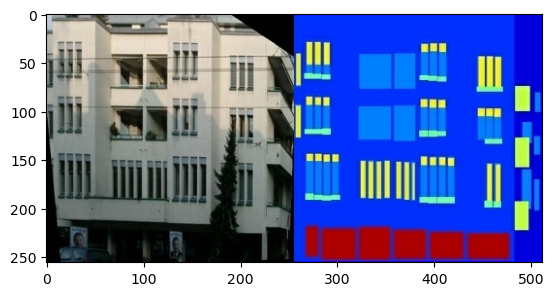

In [16]:
file_path = "/mnt/e/Deep Learning/data/fecades/train_images/1.jpg"
file = tf.io.read_file(file_path)
image = tf.io.decode_jpeg(file)

plt.imshow(image);
print(image.shape)

In [17]:
def resize_image(input_image, real_image, height, width):
    input_image = tf.image.resize(input_image, [height, width], tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    real_image = tf.image.resize(real_image, [height, width], tf.image.ResizeMethod.NEAREST_NEIGHBOR)

    return input_image, real_image

In [18]:
IMG_HEIGHT = 256
IMG_WIDTH = 256

def random_crop(input_image, real_image, IMG_HEIGHT, IMG_WIDTH):
    stacked_image = tf.stack([input_image, real_image], axis=0)
    croped_image = tf.image.random_crop(stacked_image, size=[2, IMG_HEIGHT, IMG_WIDTH, 3])

    return croped_image[0], croped_image[1]

In [46]:
def normalize_image(input_image, real_image):

    input_image = tf.cast(input_image, tf.float32)
    real_image = tf.cast(real_image, tf.float32)
    
    input_image = (input_image / 127.5) - 1
    real_image = (real_image / 127.5) - 1 

    return input_image, real_image

In [47]:
@tf.function()
def random_jiter(input_image, real_image):
    resized_input_image, resize_real_image = resize_image(input_image, real_image, 286, 286)
    croped_input_image, croped_real_image = random_crop(input_image, real_image, 256, 256)

    if tf.random.uniform(shape=()) > 0.5:
        input_image = tf.image.flip_left_right(croped_input_image)
        real_image = tf.image.flip_left_right(croped_real_image)

    return input_image, real_image

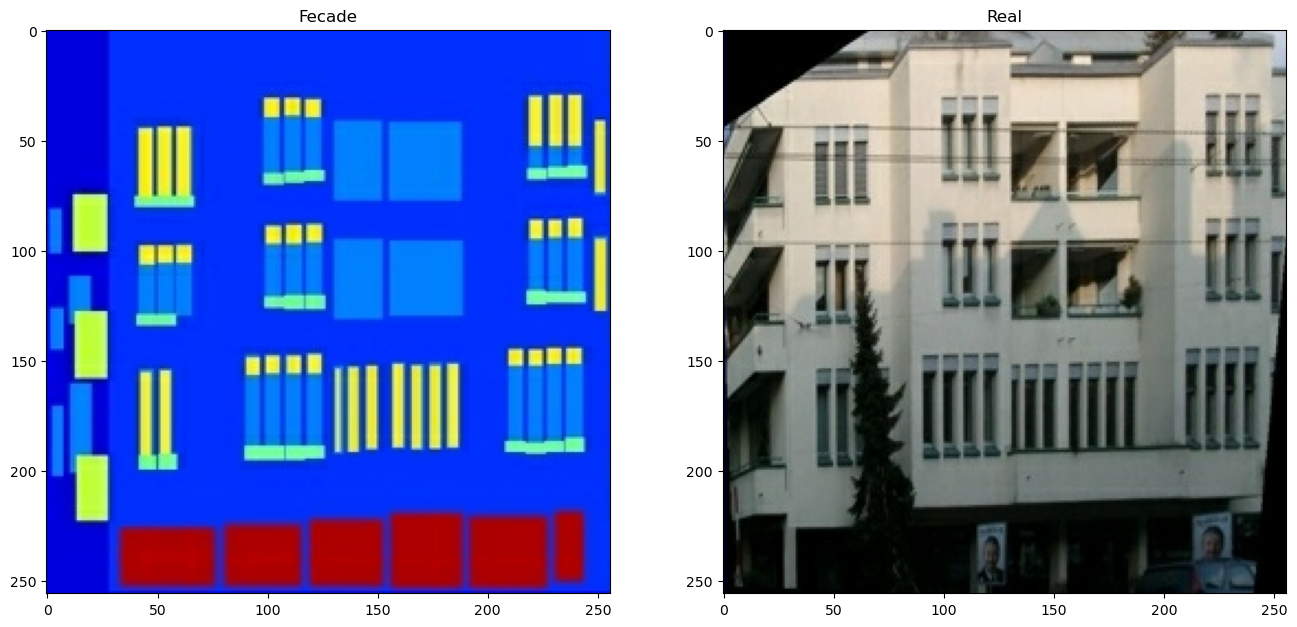

<Figure size 640x480 with 0 Axes>

In [35]:
real_image_path = "/mnt/e/Deep Learning/data/fecades/trainA/1_A.jpg"
input_image_path = "/mnt/e/Deep Learning/data/fecades/trainB/1_B.jpg"

input_image = tf.io.read_file(input_image_path)
input_image = tf.io.decode_jpeg(input_image)

real_image = tf.io.read_file(real_image_path)
real_image = tf.io.decode_jpeg(real_image)

aug_input, aug_real = random_jiter(input_image, real_image)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1); plt.imshow(aug_input); plt.title("Fecade")
plt.subplot(1, 2, 2); plt.imshow(aug_real); plt.title("Real"); 
plt.show()
plt.tight_layout()

In [36]:
def load_image(input_image_path, real_image_path):
    input_image = tf.io.read_file(input_image_path)
    input_image = tf.io.decode_jpeg(input_image)

    real_image = tf.io.read_file(real_image_path)
    real_image = tf.io.decode_jpeg(real_image)

    return input_image, real_image

In [42]:
train_real_dir = "/mnt/e/Deep Learning/data/fecades/trainA"
train_input_dir = "/mnt/e/Deep Learning/data/fecades/trainB"

test_real_dir = "/mnt/e/Deep Learning/data/fecades/testA"
test_input_dir = "/mnt/e/Deep Learning/data/fecades/testB"


print(f"TrainA: {len(os.listdir(train_real_dir))} files")
print(f"TrainB: {len(os.listdir(train_input_dir))} files")
print(f"TestA : {len(os.listdir(test_real_dir))} files")
print(f"TestB : {len(os.listdir(test_input_dir))} files")

TrainA: 400 files
TrainB: 400 files
TestA : 106 files
TestB : 106 files


In [51]:
batch_size = 1

train_loader = tf.data.Dataset.from_tensor_slices((
     [os.path.join(train_input_dir, name) for name in sorted(os.listdir(train_input_dir))],
      [os.path.join(train_real_dir, name) for name in sorted(os.listdir(train_real_dir))]
))

train_loader = train_loader.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_loader = train_loader.map(random_jiter)
train_loader = train_loader.map(normalize_image)
train_loader = train_loader.shuffle(len(train_loader))
train_loader = train_loader.prefetch(tf.data.AUTOTUNE)
train_loader  = train_loader.batch(batch_size)


In [52]:
batch_size = 1

test_loader = tf.data.Dataset.from_tensor_slices((
    [os.path.join(test_input_dir, name)
     for name in sorted(os.listdir(test_input_dir))],

    [os.path.join(test_real_dir, name)
     for name in sorted(os.listdir(test_real_dir))]
))

test_loader = test_loader.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_loader = test_loader.map(normalize_image)

test_loader = test_loader.batch(batch_size)

test_loader = test_loader.prefetch(tf.data.AUTOTUNE)

In [53]:
len(train_loader)

400

In [54]:
len(test_loader)

106

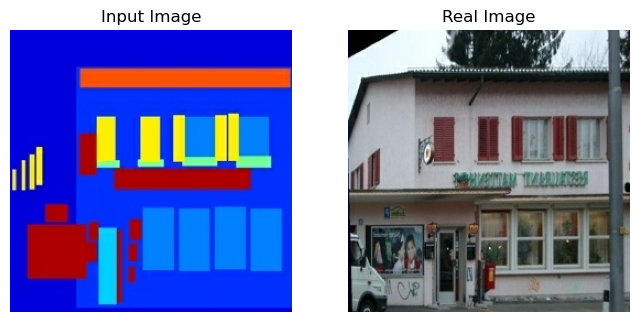

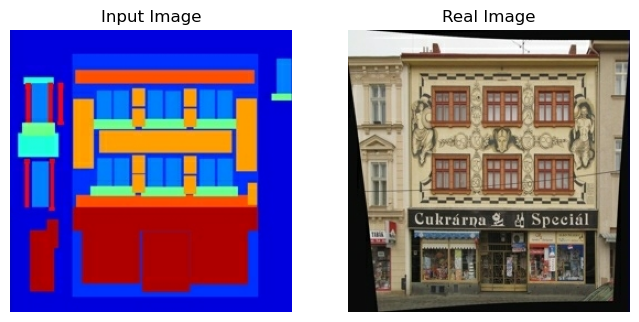

In [55]:
import matplotlib.pyplot as plt

for i, (input_image, real_image) in enumerate(train_loader.take(2)):
    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow((input_image[0] + 1) / 2)   
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow((real_image[0] + 1) / 2)
    plt.title("Real Image")
    plt.axis("off")

    plt.show()

In [ ]:
def downsampler(num_filters, kernel_size=(3, 3), apply_batchNormalization=True):
    initializer = tf.random_normal_initializer(0, 0.02)

    unit = Sequential()
    unit.add(Conv2D(num_filters, kernel_size, strides=2, padding='same', kernel_initializer=initializer, use_bias=False))

    if apply_batchNormalization:
        unit.add(BatchNormalization())
    
    unit.add(LeakyReLU())

    return unit

In [66]:
for input, image in train_loader.take(1):
    out_image = downsampler(64, (3, 3))(image)

print(out_image.shape)

(1, 128, 128, 64)


In [69]:
def upsampler(num_filters, kernel_size=(3, 3), apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)

    unit = Sequential()

    unit.add(
        Conv2DTranspose(
            filters=num_filters,
            kernel_size=kernel_size,
            strides=2,
            padding='same',
            kernel_initializer=initializer,
            use_bias=False
        )
    )

    unit.add(BatchNormalization())

    if apply_dropout:
        unit.add(Dropout(0.5))

    unit.add(ReLU())

    return unit